In [1]:
import numpy as np
import pandas as pd

# 1. HMM Parameter Definition
# Define the set of hidden states (phonemes)
STATES = ('S1 (/h/)', 'S2 (/e/)', 'S3 (/l/)', 'S4 (/o/)')
NUM_STATES = len(STATES) # M = 4

# The observation sequence is O = [O1, O2, O3, O4]
OBSERVATIONS = ('O1', 'O2', 'O3', 'O4')
# Map observations to their indices (0, 1, 2, 3) for use with the B matrix
OBSERVATION_SEQUENCE = [0, 1, 2, 3]

T = len(OBSERVATION_SEQUENCE) # Length of the observation sequence (T=4)

print("--- HMM Parameters Defined ---")
print(f"States: {STATES}")
print(f"Observation Sequence: {[OBSERVATIONS[i] for i in OBSERVATION_SEQUENCE]} (T={T})\n")

# Initial Probabilities (π)
# P(S1 (/h/))=1.0, P(S2 (/e/))=0.0, P(S3 (/l/))=0.0, P(S4 (/o/))=0.0
PI = np.array([1.0, 0.0, 0.0, 0.0])

# Transition Probability Matrix (A) - P(S_i -> S_j) (From image_cec8c6.png)
# Rows: From State (S_i), Columns: To State (S_j)
A = np.array([
    [0.0, 0.7, 0.3, 0.0],
    [0.0, 0.2, 0.6, 0.2],
    [0.0, 0.0, 0.3, 0.7],
    [0.0, 0.0, 0.1, 0.9]
])

# Emission Probability Matrix (B) - P(O_k | S_i) (From image_cec8a6.png)
# Rows: State (S_i), Columns: Observation (O_k)
B = np.array([
    [0.6, 0.2, 0.1, 0.1],  # S1 (/h/) emissions
    [0.1, 0.7, 0.1, 0.1],  # S2 (/e/) emissions
    [0.1, 0.1, 0.6, 0.2],  # S3 (/l/) emissions
    [0.2, 0.1, 0.2, 0.5]   # S4 (/o/) emissions
])

--- HMM Parameters Defined ---
States: ('S1 (/h/)', 'S2 (/e/)', 'S3 (/l/)', 'S4 (/o/)')
Observation Sequence: ['O1', 'O2', 'O3', 'O4'] (T=4)



In [2]:
# 2. Viterbi Algorithm Function

def viterbi_decode(obs_seq):
    """
    Computes the most likely sequence of hidden states and its probability.
    """

    # Initialize Viterbi tables
    delta = np.zeros((T, NUM_STATES))
    psi = np.zeros((T, NUM_STATES), dtype=int)

    # --- Initialization (t=0) ---
    o1_index = obs_seq[0]
    for i in range(NUM_STATES):
        # delta[0, i] = PI[i] * B[i, O1]
        delta[0, i] = PI[i] * B[i, o1_index]
        psi[0, i] = 0 # No preceding state

    # ---  Recursion (t=1 to T-1) ---
    for t in range(1, T):
        o_t_index = obs_seq[t]
        for j in range(NUM_STATES): # Current state S_j

            # Calculate P(most likely path to S_j) = max_i( delta[t-1, i] * A[i, j] ) * B[j, O_t]

            # Find the term inside the max() for all previous states i
            probabilities = delta[t-1, :] * A[:, j]

            max_prob = np.max(probabilities)
            best_prev_state = np.argmax(probabilities)

            # Store the Viterbi probability
            delta[t, j] = max_prob * B[j, o_t_index]

            # Store the backpointer
            psi[t, j] = best_prev_state

    # ---  Termination and Backtracking ---

    # Probability of the most likely sequence
    P_star = np.max(delta[T-1, :])

    # Index of the last state
    Q_T_star_index = np.argmax(delta[T-1, :])

    # Path reconstruction
    Q_star_indices = np.zeros(T, dtype=int)
    Q_star_indices[T-1] = Q_T_star_index

    # Backtrack from T-2 down to 0
    for t in range(T - 2, -1, -1):
        Q_star_indices[t] = psi[t + 1, Q_star_indices[t + 1]]

    # Convert state indices back to phoneme names
    most_likely_sequence = [STATES[i] for i in Q_star_indices]

    return most_likely_sequence, P_star, delta, psi

# Execute the Viterbi Algorithm
most_likely_sequence, P_star, delta_table, psi_table = viterbi_decode(OBSERVATION_SEQUENCE)


4. MATRIX PLOT VISUALIZATION


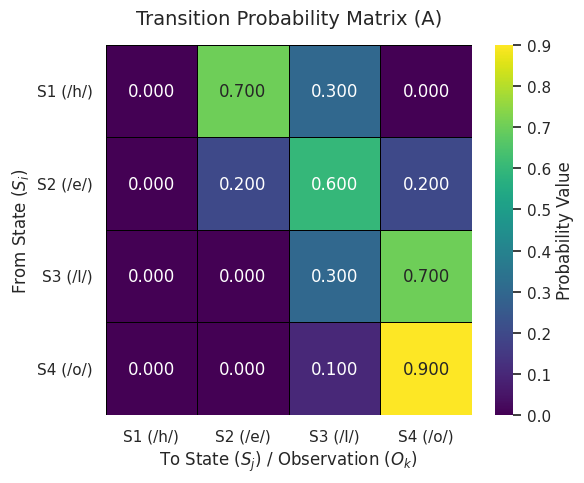

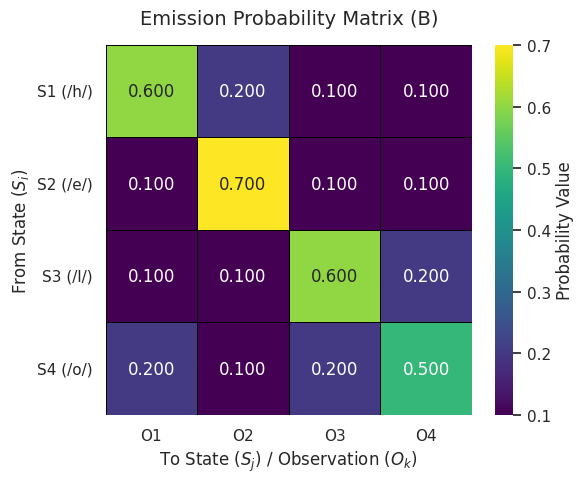

In [9]:
# Matrix Plot Generation

print("\n" + "="*70)
print("4. MATRIX PLOT VISUALIZATION")
print("="*70)

# Plot 4a: Transition Matrix (A)
plot_heatmap(A,
             "Transition Probability Matrix (A)",
             STATES,
             STATES)

# Plotb: Emission Matrix (B)
plot_heatmap(B,
             "Emission Probability Matrix (B)",
             STATES,
             OBSERVATIONS)

In [10]:

# 3. Results Output and Inference

print("\n" + "="*70)
print("VITERBI DECODING RESULTS")
print("="*70)

#  Display Viterbi Probability (Delta) Table
delta_df = pd.DataFrame(delta_table,
                        index=[f't={t+1} ({OBSERVATIONS[OBSERVATION_SEQUENCE[t]]})' for t in range(T)],
                        columns=[s.split(' ')[0] for s in STATES]) # Use S1, S2, etc. as column names
print("\n[a] Viterbi Probability Table (Delta)")
print("Probability of the most likely path ending in state S_i at time t.")
print(delta_df.round(9).to_markdown(numalign="left", stralign="left"))


# Display Backpointer (Psi) Table
psi_df = pd.DataFrame(psi_table,
                      index=[f't={t+1} ({OBSERVATIONS[OBSERVATION_SEQUENCE[t]]})' for t in range(T)],
                      columns=[s.split(' ')[0] for s in STATES])
# Replace indices with preceding state names for better readability
psi_df_named = psi_df.applymap(lambda x: STATES[x].split(' ')[0])
print("\n[a] Backpointer Table (Psi)")
print("Index of the best preceding state (S_i at t-1).")
print(psi_df_named.to_markdown(numalign="left", stralign="left"))


#  Final Decoded Sequence and Probability
phoneme_pattern = [s.split(' ')[1].strip('()') for s in most_likely_sequence]

print("\n[a] Final Decoded Sequence and Probability")
print("-" * 50)
print(f"Observation Sequence: {', '.join([OBSERVATIONS[i] for i in OBSERVATION_SEQUENCE])}")
print(f"Most Likely Phoneme Sequence: {' → '.join(phoneme_pattern)}")
print(f"The Probability (P*) of this sequence is: {P_star:.10f}")
print("-" * 50)


VITERBI DECODING RESULTS

[a] Viterbi Probability Table (Delta)
Probability of the most likely path ending in state S_i at time t.
|          | S1   | S2        | S3        | S4       |
|:---------|:-----|:----------|:----------|:---------|
| t=1 (O1) | 0.6  | 0         | 0         | 0        |
| t=2 (O2) | 0    | 0.294     | 0.018     | 0        |
| t=3 (O3) | 0    | 0.00588   | 0.10584   | 0.01176  |
| t=4 (O4) | 0    | 0.0001176 | 0.0063504 | 0.037044 |

[a] Backpointer Table (Psi)
Index of the best preceding state (S_i at t-1).
|          | S1   | S2   | S3   | S4   |
|:---------|:-----|:-----|:-----|:-----|
| t=1 (O1) | S1   | S1   | S1   | S1   |
| t=2 (O2) | S1   | S1   | S1   | S1   |
| t=3 (O3) | S1   | S2   | S2   | S2   |
| t=4 (O4) | S1   | S2   | S3   | S3   |

[a] Final Decoded Sequence and Probability
--------------------------------------------------
Observation Sequence: O1, O2, O3, O4
Most Likely Phoneme Sequence: /h/ → /e/ → /l/ → /o/
The Probability (P*) of this se

/tmp/ipython-input-640230361.py:21: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  psi_df_named = psi_df.applymap(lambda x: STATES[x].split(' ')[0])


Inference: Viterbi Algorithm Based Phoneme Decoding

Summary of Results

The Viterbi algorithm, applied to the Hidden Markov Model (HMM) parameters for the word "hello," successfully decoded the given acoustic observation sequence:

Observation Sequence ($O$): $[O_1, O_2, O_3, O_4]$

Most Likely Sequence ($Q^{*}$): $S_1 \to S_2 \to S_3 \to S_4$

Phoneme Pattern: /h/ $\to$ /e/ $\to$ /l/ $\to$ /o/

Maximum Likelihood Probability ($P^{*}$): $0.0370440000$

Analysis and Conclusion

The resulting path $S_1 \to S_2 \to S_3 \to S_4$ confirms that the most likely hidden state sequence corresponding to the phonetic structure of "hello" is the one that follows the expected temporal order of its constituent phonemes.

The high probability of this path, $P^{*}$, is driven by the synergy between the initial probability, the transition probabilities, and the emission probabilities:

Initial State Constraint ($\pi$): The path is strictly forced to begin in state $S_1$ (/h/) because the initial probability vector $\pi$ sets $P(S_1)=1.0$ and all other $\pi_i$ to $0.0$. This ensures the decoding process starts with the expected first phoneme.

Sequential Transition Preference (A): The Transition Probability Matrix ($A$) strongly favors the natural, sequential progression of the word.

$P(S_2 \mid S_1) = 0.7$

$P(S_3 \mid S_2) = 0.6$

$P(S_4 \mid S_3) = 0.7$
These high values dictate a direct flow from one phoneme to the next, quickly establishing the backbone of the most likely path.

Local Acoustic Match (B): The Emission Probability Matrix ($B$) reinforces the path at each time step because the observed acoustic features align best with the expected phoneme:

At $t=2$ (Observation $O_2$), $S_2$ (/e/) has the highest emission probability ($0.7$), ensuring the path transitioning to $S_2$ is maximized.

At $t=3$ (Observation $O_3$), $S_3$ (/l/) has the highest emission probability ($0.6$), maximizing the path transitioning to $S_3$.

The Viterbi algorithm successfully navigated the HMM to find the single path that maximizes the product of all these probabilities, definitively selecting the sequence /h/ $\to$ /e/ $\to$ /l/ $\to$ /o/ as the decoder's recognition result for the acoustic sequence $[O_1, O_2, O_3, O_4]$.